In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("/content/spambase.data", header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [3]:
print("Total samples: " + str(X.shape[0]))
print("Features: " + str(X.shape[1]))
print("Train: "+ str(X_train.shape[0]))
print("Test: " + str(X_test.shape[0]))


Total samples: 4601
Features: 57
Train: 3450
Test: 1151


In [11]:
# 3.1

n_trees = [10, 50, 100, 500]
li = {}
for T in n_trees:
    mod = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=T, random_state=42, algorithm="SAMME")
    mod.fit(X_train, y_train)
    li[T] = mod

    pred_train = mod.predict(X_train)
    prob_train = mod.predict_proba(X_train)[:, 1]
    pred_test = mod.predict(X_test)
    prob_test = mod.predict_proba(X_test)[:, 1]

    acc1 = accuracy_score(y_train, pred_train)
    f1_1 = f1_score(y_train, pred_train)
    auc_1 = roc_auc_score(y_train, prob_train)

    acc2 = accuracy_score(y_test, pred_test)
    f1_2 = f1_score(y_test, pred_test)
    auc_2 = roc_auc_score(y_test, prob_test)

    print("T = " + str(T) + " base learners:")
    print("Training Accuracy: " + str(acc1))
    print("Training F1: " + str(f1_1))
    print("Training AUC: " + str(auc_1))
    print("Testing Accuracy: " + str(acc2))
    print("Testing F1: " + str(f1_2))
    print("Testing AUC: " + str(auc_2))
    print()

T = 10 base learners:
Training Accuracy: 0.9142028985507247
Training F1: 0.8879636638909917
Training AUC: 0.9643458477714364
Testing Accuracy: 0.9148566463944396
Testing F1: 0.8934782608695652
Testing AUC: 0.9663064465898474

T = 50 base learners:
Training Accuracy: 0.9310144927536231
Training F1: 0.9106606606606606
Training AUC: 0.9789278009919826
Testing Accuracy: 0.9357080799304952
Testing F1: 0.9204301075268817
Testing AUC: 0.9799953285580816

T = 100 base learners:
Training Accuracy: 0.9356521739130435
Training F1: 0.9155893536121673
Training AUC: 0.9820985216514925
Testing Accuracy: 0.9357080799304952
Testing F1: 0.9195652173913044
Testing AUC: 0.98191373403924

T = 500 base learners:
Training Accuracy: 0.948695652173913
Training F1: 0.9329291398256916
Training AUC: 0.9898002587534538
Testing Accuracy: 0.947871416159861
Testing F1: 0.9356223175965666
Testing AUC: 0.9853597010277172



In [12]:
# 3.2


li2 = {}
for T in n_trees:
    mod = RandomForestClassifier(n_estimators=T, random_state=42)
    mod.fit(X_train, y_train)
    li2[T] = mod

for T in n_trees:
    pred_test1 = li2[T].predict(X_test)
    prob_test1 = li2[T].predict_proba(X_test)[:, 1]
    acc1 = accuracy_score(y_test, pred_test1)
    f1_1 = f1_score(y_test, pred_test1)
    auc_1 = roc_auc_score(y_test, prob_test1)

    pred_test2 = li[T].predict(X_test)
    prob_test2 = li[T].predict_proba(X_test)[:, 1]
    acc2 = accuracy_score(y_test, pred_test2)
    f1_2 = f1_score(y_test, pred_test2)
    auc_2 = roc_auc_score(y_test, prob_test2)

    print("T = " + str(T) + ":")
    print("RF Accuracy: " + str(acc1))
    print("RF F1: " + str(f1_1))
    print("RF AUC: " + str(auc_1))
    print("AdaBoost Accuracy: " + str(acc2))
    print("AdaBoost F1: " + str(f1_2))
    print("AdaBoost AUC: " + str(auc_2))
    print()

T = 10:
RF Accuracy: 0.946133796698523
RF F1: 0.9329004329004329
RF AUC: 0.9817580193086267
AdaBoost Accuracy: 0.9148566463944396
AdaBoost F1: 0.8934782608695652
AdaBoost AUC: 0.9663064465898474

T = 50:
RF Accuracy: 0.9582971329278888
RF F1: 0.9481641468682506
RF AUC: 0.9884132668950483
AdaBoost Accuracy: 0.9357080799304952
AdaBoost F1: 0.9204301075268817
AdaBoost AUC: 0.9799953285580816

T = 100:
RF Accuracy: 0.9582971329278888
RF F1: 0.9481641468682506
RF AUC: 0.9879165369043913
AdaBoost Accuracy: 0.9357080799304952
AdaBoost F1: 0.9195652173913044
AdaBoost AUC: 0.98191373403924

T = 500:
RF Accuracy: 0.9582971329278888
RF F1: 0.9482758620689655
RF AUC: 0.9876128931796947
AdaBoost Accuracy: 0.947871416159861
AdaBoost F1: 0.9356223175965666
AdaBoost AUC: 0.9853597010277172



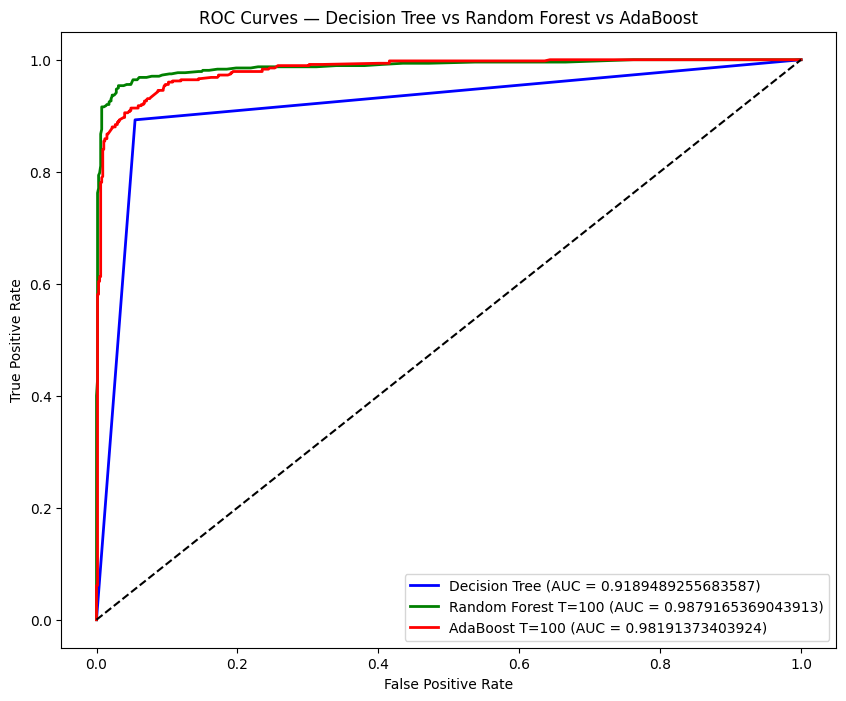

AUC — Decision Tree: 0.9189489255683587
AUC — Random Forest (T=100): 0.9879165369043913
AUC — AdaBoost (T=100): 0.98191373403924


In [13]:
## 3.3


# decision tree
mod_dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
mod_dt.fit(X_train, y_train)
prob1 = mod_dt.predict_proba(X_test)[:, 1]
fpr1, tpr1, _ = roc_curve(y_test, prob1)
auc_1 = roc_auc_score(y_test, prob1)

# random forest T=100
prob2 = li2[100].predict_proba(X_test)[:, 1]
fpr2, tpr2, _ = roc_curve(y_test, prob2)
auc_2 = roc_auc_score(y_test, prob2)

# adaboost T=100
prob3 = li[100].predict_proba(X_test)[:, 1]
fpr3, tpr3, _ = roc_curve(y_test, prob3)
auc_3 = roc_auc_score(y_test, prob3)

plt.figure(figsize=(10, 8))
plt.plot(fpr1, tpr1, "b-", linewidth=2, label="Decision Tree (AUC = " + str(auc_1) + ")")
plt.plot(fpr2, tpr2, "g-", linewidth=2, label="Random Forest T=100 (AUC = " + str(auc_2) + ")")
plt.plot(fpr3, tpr3, "r-", linewidth=2, label="AdaBoost T=100 (AUC = " + str(auc_3) + ")")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Decision Tree vs Random Forest vs AdaBoost")
plt.legend()
plt.show()

print("AUC — Decision Tree: " + str(auc_1))
print("AUC — Random Forest (T=100): " + str(auc_2))
print("AUC — AdaBoost (T=100): " + str(auc_3))